In [5]:
# ============================================================
# PART B: UNSUPERVISED LEARNING – CUSTOMER SEGMENTATION
# ============================================================

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and clustering libraries
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Ignore warnings for clean output
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")




In [6]:
# ============================================================
# STEP 1: LOAD DATA
# ============================================================
def load_data(file_path):
    """
    Loads the dataset from a CSV file and prints basic information.
    """
    df = pd.read_csv(file_path)

    print("Dataset Loaded Successfully")
    print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
    print("\nColumn Names:")
    print(df.columns)
    print("\nFirst 5 Records:")
    print(df.head())
    print("\nDataset Info:")
    print(df.info())

    return df


# ============================================================
# STEP 2: DATA PREPROCESSING & FEATURE ENGINEERING
# ============================================================
def preprocess_data(df):
    """
    Aggregates order-level data into customer-level features
    suitable for clustering.
    """

    print("\nChecking missing values:")
    print(df.isnull().sum())

    customer_features = []

    # Aggregate data at customer level
    for customer_id in df['customer'].unique():
        customer_data = df[df['customer'] == customer_id]

        # Basic behavioral features
        num_orders = customer_data.shape[0]
        avg_items = customer_data['total_items'].mean()
        avg_discount = customer_data['discount%'].mean()
        avg_hour = customer_data['hour'].mean()
        weekday_mode = customer_data['weekday'].mode()[0]

        # Average spending across product categories
        food = customer_data['Food%'].mean()
        fresh = customer_data['Fresh%'].mean()
        drinks = customer_data['Drinks%'].mean()
        home = customer_data['Home%'].mean()
        beauty = customer_data['Beauty%'].mean()
        health = customer_data['Health%'].mean()
        baby = customer_data['Baby%'].mean()
        pets = customer_data['Pets%'].mean()

        # Category diversity (entropy)
        categories = np.array([food, fresh, drinks, home, beauty, health, baby, pets]) / 100
        categories += 1e-10
        categories = categories / categories.sum()
        entropy = -np.sum(categories * np.log(categories))

        # Store customer-level features
        customer_features.append({
            'customer_id': customer_id,
            'num_orders': num_orders,
            'avg_items': avg_items,
            'avg_discount': avg_discount,
            'avg_hour': avg_hour,
            'weekday_mode': weekday_mode,
            'food_avg': food,
            'fresh_avg': fresh,
            'drinks_avg': drinks,
            'home_avg': home,
            'beauty_avg': beauty,
            'health_avg': health,
            'baby_avg': baby,
            'pets_avg': pets,
            'category_entropy': entropy
        })

    customer_df = pd.DataFrame(customer_features)

    print("\nCustomer-level dataset created")
    print(customer_df.describe())

    return customer_df


# ============================================================
# STEP 3: FEATURE SELECTION & SCALING
# ============================================================
def prepare_clustering_data(customer_df):
    """
    Selects relevant features and applies standard scaling.
    """

    feature_cols = [
        'num_orders', 'avg_items', 'avg_discount', 'avg_hour', 'weekday_mode',
        'food_avg', 'fresh_avg', 'drinks_avg', 'home_avg',
        'beauty_avg', 'health_avg', 'baby_avg', 'pets_avg',
        'category_entropy'
    ]

    X = customer_df[feature_cols]

    # Handle missing values if any
    X = X.fillna(X.mean())

    # Scale the features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    print("\nFeatures scaled for clustering")

    return X_scaled, X, feature_cols


# ============================================================
# STEP 4: DETERMINE OPTIMAL NUMBER OF CLUSTERS
# ============================================================
def find_optimal_k(X_scaled, max_k=8):
    """
    Uses Elbow Method and Silhouette Score to determine optimal k.
    """

    wcss = []
    silhouette_scores = []

    for k in range(2, max_k + 1):
        model = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = model.fit_predict(X_scaled)
        wcss.append(model.inertia_)
        silhouette_scores.append(silhouette_score(X_scaled, labels))
        print(f"k={k}, Silhouette Score={silhouette_scores[-1]:.3f}")

    # Plot results
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(range(2, max_k+1), wcss, marker='o')
    plt.title("Elbow Method")
    plt.xlabel("Number of Clusters")
    plt.ylabel("WCSS")

    plt.subplot(1,2,2)
    plt.plot(range(2, max_k+1), silhouette_scores, marker='o')
    plt.title("Silhouette Scores")
    plt.xlabel("Number of Clusters")
    plt.ylabel("Score")

    plt.tight_layout()
    plt.show()

    optimal_k = range(2, max_k+1)[np.argmax(silhouette_scores)]
    print(f"\nOptimal number of clusters selected: {optimal_k}")

    return optimal_k



In [7]:

# ============================================================
# STEP 5: APPLY K-MEANS CLUSTERING
# ============================================================
def perform_kmeans(X_scaled, customer_df, k):
    """
    Applies K-Means clustering and evaluates performance.
    """

    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    clusters = model.fit_predict(X_scaled)

    customer_df['cluster'] = clusters

    print("\nClustering Evaluation Metrics:")
    print(f"Silhouette Score: {silhouette_score(X_scaled, clusters):.3f}")
    print(f"Davies-Bouldin Index: {davies_bouldin_score(X_scaled, clusters):.3f}")
    print(f"Calinski-Harabasz Index: {calinski_harabasz_score(X_scaled, clusters):.3f}")

    print("\nCluster Distribution:")
    print(customer_df['cluster'].value_counts())

    return model, customer_df


# ============================================================
# STEP 6: CLUSTER VISUALIZATION USING PCA
# ============================================================
def visualize_clusters(X_scaled, customer_df, model):
    """
    Visualizes clusters using PCA.
    """

    pca = PCA(n_components=2)
    components = pca.fit_transform(X_scaled)

    plt.figure(figsize=(10,7))
    plt.scatter(components[:,0], components[:,1],
                c=customer_df['cluster'], cmap='viridis', alpha=0.7)
    plt.scatter(pca.transform(model.cluster_centers_)[:,0],
                pca.transform(model.cluster_centers_)[:,1],
                c='red', marker='X', s=200, label='Centroids')

    plt.title("Customer Segments (PCA Projection)")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.legend()
    plt.show()


# ============================================================
# STEP 7: CLUSTER PROFILING
# ============================================================
def profile_clusters(customer_df):
    """
    Profiles clusters by analyzing average behavior.
    """

    print("\nCLUSTER PROFILES")
    print("="*50)

    for cluster in sorted(customer_df['cluster'].unique()):
        subset = customer_df[customer_df['cluster'] == cluster]

        print(f"\nCluster {cluster}")
        print(f"Size: {len(subset)} customers")
        print(subset.mean(numeric_only=True))




Dataset Loaded Successfully
Rows: 30000, Columns: 14

Column Names:
Index(['customer', 'order', 'total_items', 'discount%', 'weekday', 'hour',
       'Food%', 'Fresh%', 'Drinks%', 'Home%', 'Beauty%', 'Health%', 'Baby%',
       'Pets%'],
      dtype='object')

First 5 Records:
   customer  order  total_items  discount%  weekday  hour  Food%  Fresh%  \
0         0      0           45      23.03        4    13   9.46   87.06   
1         0      1           38       1.22        5    13  15.87   75.80   
2         0      2           51      18.08        4    13  16.88   56.75   
3         1      3           57      16.51        1    12  28.81   35.99   
4         1      4           53      18.31        2    11  24.13   60.38   

   Drinks%  Home%  Beauty%  Health%  Baby%  Pets%  
0     3.48   0.00     0.00     0.00    0.0    0.0  
1     6.22   2.12     0.00     0.00    0.0    0.0  
2     3.37  16.48     6.53     0.00    0.0    0.0  
3    11.78   4.62     2.87    15.92    0.0    0.0  
4     

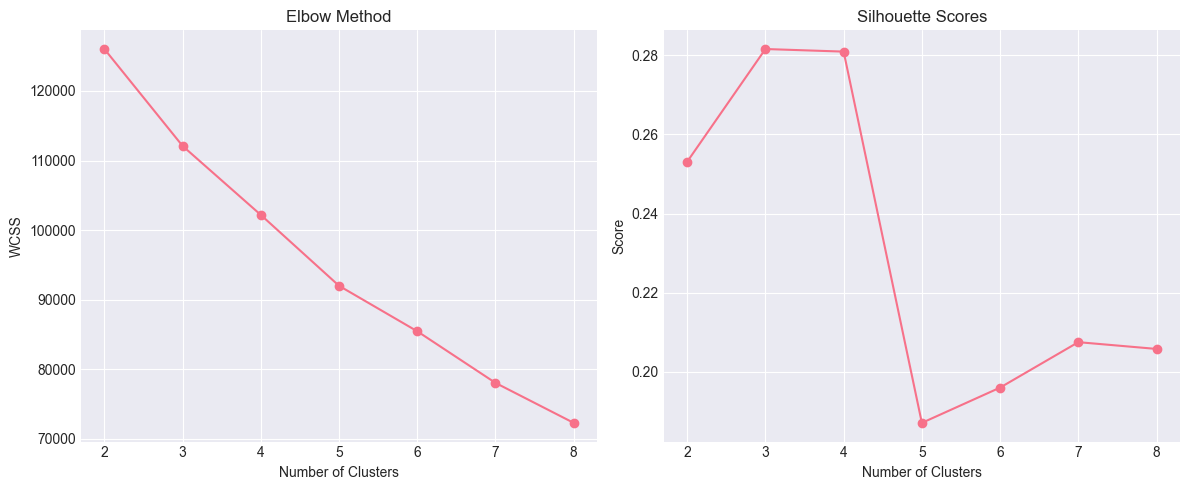


Optimal number of clusters selected: 3

Clustering Evaluation Metrics:
Silhouette Score: 0.282
Davies-Bouldin Index: 1.490
Calinski-Harabasz Index: 1426.883

Cluster Distribution:
cluster
0    8163
2    1668
1     408
Name: count, dtype: int64


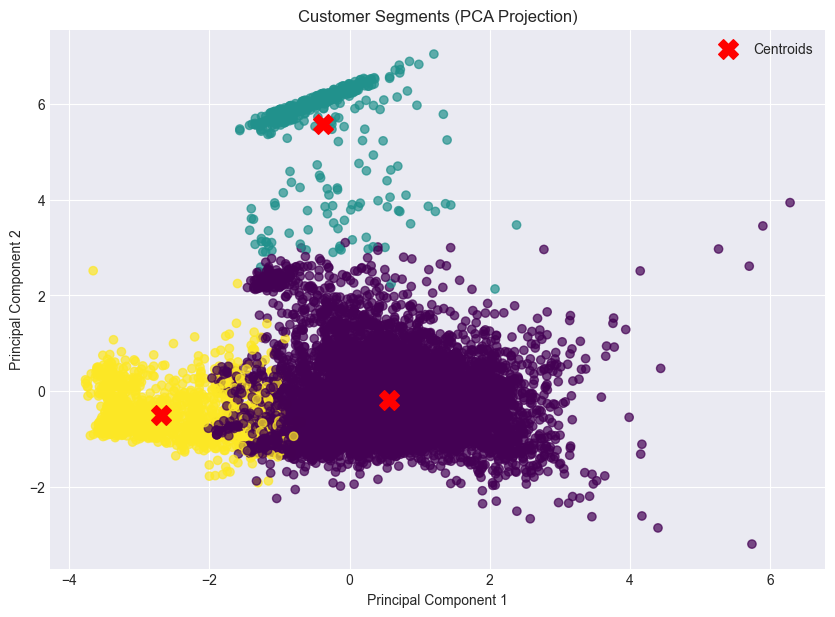


CLUSTER PROFILES

Cluster 0
Size: 8163 customers
customer_id         5166.782188
num_orders             3.298542
avg_items             33.059046
avg_discount           7.828631
avg_hour              15.261763
weekday_mode           3.139165
food_avg              24.878923
fresh_avg             17.440917
drinks_avg            27.131854
home_avg              17.565054
beauty_avg             5.426792
health_avg             1.249340
baby_avg               5.147918
pets_avg               1.029710
category_entropy       1.161108
cluster                0.000000
dtype: float64

Cluster 1
Size: 408 customers
customer_id         3358.176471
num_orders             1.254902
avg_items             49.823500
avg_discount          91.012496
avg_hour              15.497222
weekday_mode           3.529412
food_avg              96.464036
fresh_avg              0.606171
drinks_avg             1.019210
home_avg               0.812837
beauty_avg             0.486493
health_avg             0.106846
baby_avg

In [8]:
# ============================================================
# MAIN EXECUTION PIPELINE
# ============================================================
def main():
    df = load_data("Part_B_Dataset.csv")
    customer_df = preprocess_data(df)
    X_scaled, X_original, features = prepare_clustering_data(customer_df)
    optimal_k = find_optimal_k(X_scaled)
    model, labeled_df = perform_kmeans(X_scaled, customer_df, optimal_k)
    visualize_clusters(X_scaled, labeled_df, model)
    profile_clusters(labeled_df)

    return labeled_df


# Run the full pipeline
if __name__ == "__main__":
    segmented_customers = main()

